In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('sampledata.csv')
df

,emp_name,department,join_date,salary,age,performance_rating,city,remote_work
0,Employee_1,Engineering,2018-01-01 00:00:00,60820.29,51.0,4.0,Pune,No
1,Employee_2,NaN,2018-01-08 20:04:01,48271.19,30.0,3.0,Delhi,No
2,Employee_3,HR,2018-01-16 16:08:02,98590.99,55.0,2.0,Mumbai,No
3,Employee_4,Marketing,2018-01-24 12:12:02,71410.54,56.0,3.0,Mumbai,No
4,Employee_5,Sales,2018-02-01 08:16:03,23547.43,43.0,4.0,Chennai,yes
...,...,...,...,...,...,...,...,...
303,Employee_214,Sales,2022-07-28 02:14:51,72054.11,39.0,3.0,Pune,No
304,Employee_107,Engineering,2020-04-10 15:05:25,67432.77,46.0,4.0,Bangalore,Yes
305,Employee_128,Finance,2020-09-22 04:29:42,NaN,29.0,4.0,Bangalore,No
306,Employee_177,Marketing,2021-10-11 03:46:21,62165.32,51.0,4.0,Bangalore,NO


ANALYZING THE DATA

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            308 non-null    str    
 1   department          295 non-null    str    
 2   join_date           308 non-null    str    
 3   salary              290 non-null    float64
 4   age                 298 non-null    float64
 5   performance_rating  291 non-null    float64
 6   city                308 non-null    str    
 7   remote_work         281 non-null    str    
dtypes: float64(3), str(5)
memory usage: 19.4 KB


In [3]:
df.shape

(308, 8)

In [4]:
df.describe()

,salary,age,performance_rating
count,290.000000,298.000000,291.000000
mean,59624.215000,41.600671,3.584192
std,17629.028021,10.800842,1.071073
min,1657.190000,22.000000,1.000000
25%,47116.487500,33.000000,3.000000
50%,59723.160000,42.000000,4.000000
75%,71327.545000,51.000000,4.000000
max,115419.850000,59.000000,5.000000


CHECKING MISSING VALUES

In [5]:
df.isnull().sum()

emp_name               0
department            13
join_date              0
salary                18
age                   10
performance_rating    17
city                   0
remote_work           27
dtype: int64

In [6]:
df.value_counts()

emp_name      department   join_date            salary    age   performance_rating  city       remote_work
Employee_74   Finance      2019-07-27 00:52:59  62111.89  30.0  2.0                 Bangalore  Yes            2
Employee_107  Engineering  2020-04-10 15:05:25  67432.77  46.0  4.0                 Bangalore  Yes            2
Employee_177  Marketing    2021-10-11 03:46:21  62165.32  51.0  4.0                 Bangalore  NO             2
Employee_214  Sales        2022-07-28 02:14:51  72054.11  39.0  3.0                 Pune       No             2
Employee_1    Engineering  2018-01-01 00:00:00  60820.29  51.0  4.0                 Pune       No             1
                                                                                                             ..
Employee_296  Engineering  2024-04-30 15:43:57  60865.53  55.0  2.0                 Chennai    No             1
Employee_297  SALES        2024-05-08 11:47:58  64675.01  45.0  5.0                 Delhi      No            

In [7]:
df.duplicated().sum()

np.int64(8)

HANDLING MISSING VALUES

In [8]:
df=df.dropna()
df.isnull().sum()

emp_name              0
department            0
join_date             0
salary                0
age                   0
performance_rating    0
city                  0
remote_work           0
dtype: int64

In [9]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()
df.shape
df['remote_work']=df['remote_work'].str.strip().str.lower()

<class 'pandas.DataFrame'>
Index: 230 entries, 0 to 299
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   emp_name            230 non-null    str    
 1   department          230 non-null    str    
 2   join_date           230 non-null    str    
 3   salary              230 non-null    float64
 4   age                 230 non-null    float64
 5   performance_rating  230 non-null    float64
 6   city                230 non-null    str    
 7   remote_work         230 non-null    str    
dtypes: float64(3), str(5)
memory usage: 16.2 KB


VISUALIZATION OF DATA

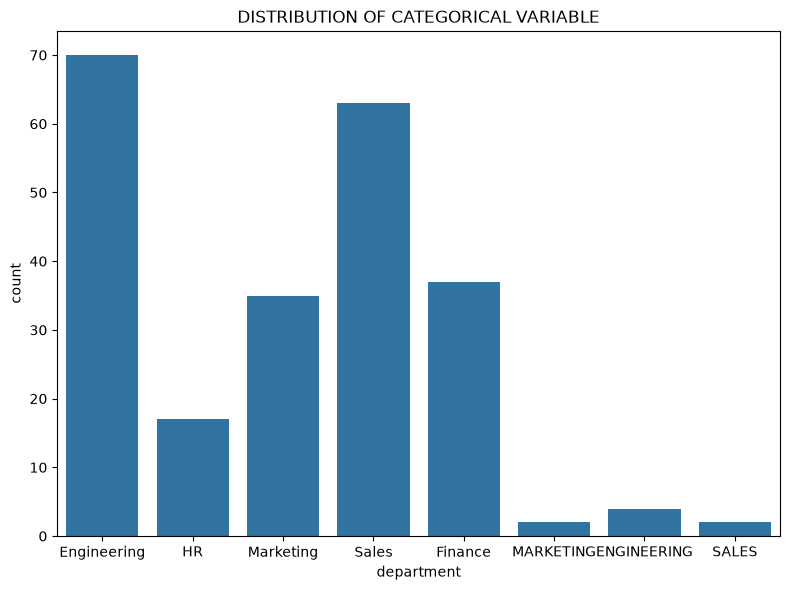

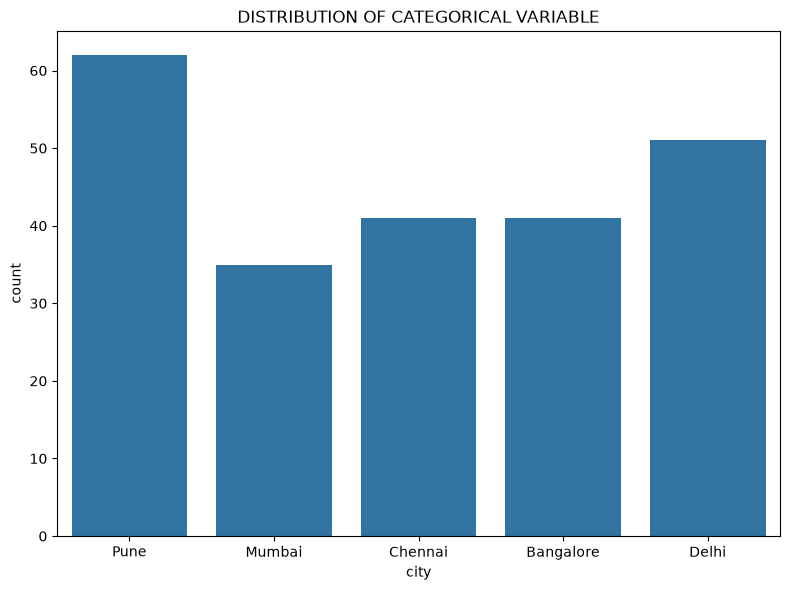

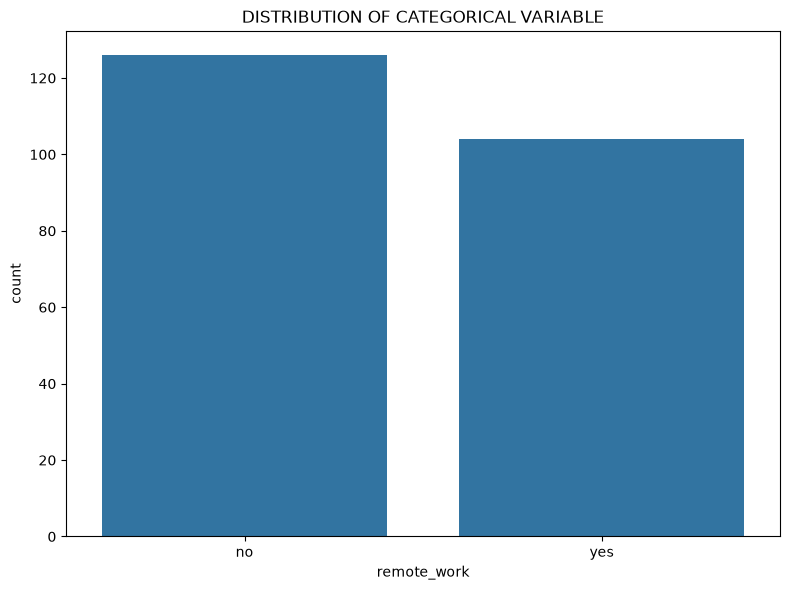

In [12]:
cat_features=['department','city','remote_work']
for col in cat_features:
    plt.figure(figsize=(8,6))
    plt.title("DISTRIBUTION OF CATEGORICAL VARIABLE")
    sns.countplot(x=df[col])
    plt.tight_layout()

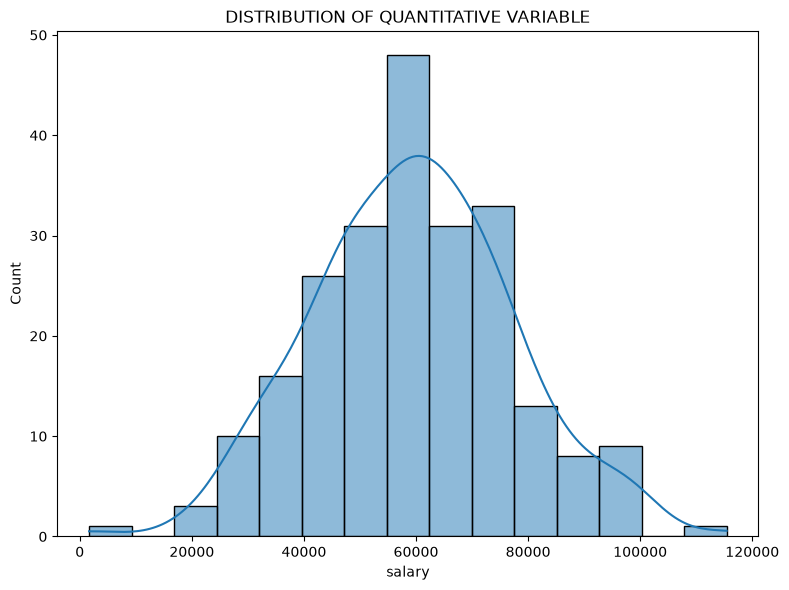

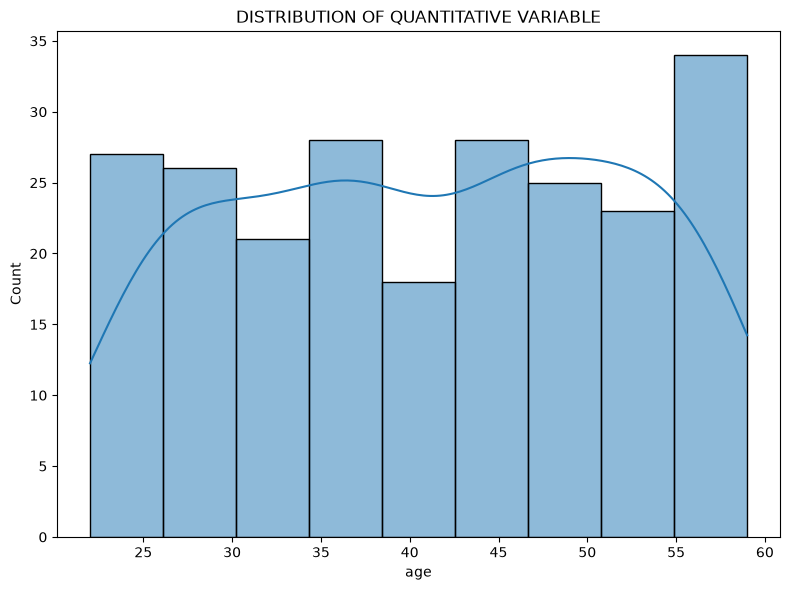

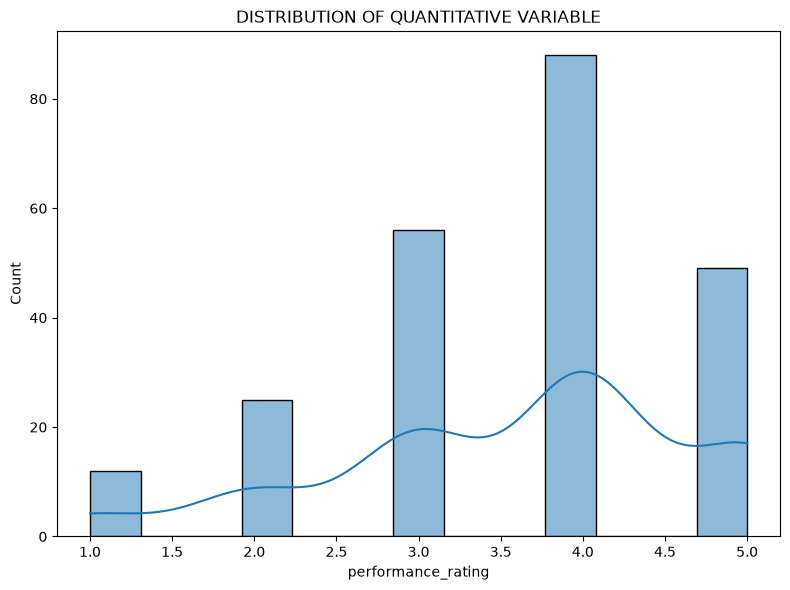

In [13]:
num_features=['salary','age','performance_rating']
for col in num_features:
    plt.figure(figsize=(8,6))
    plt.title("DISTRIBUTION OF QUANTITATIVE VARIABLE")
    sns.histplot(x=df[col],kde=True)
    plt.tight_layout()

HANDLING OUTLIERS

<Axes: ylabel='age'>

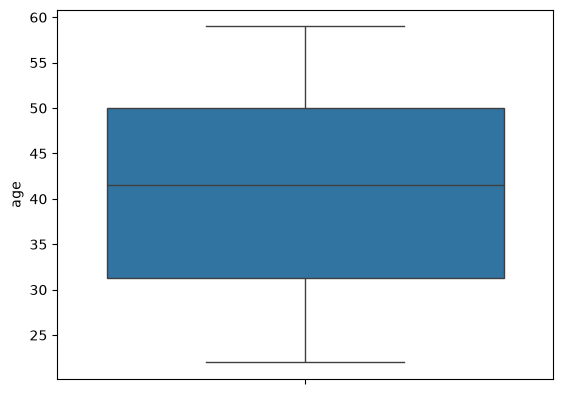

In [13]:
sns.boxplot(df['age'])





<Axes: ylabel='performance_rating'>

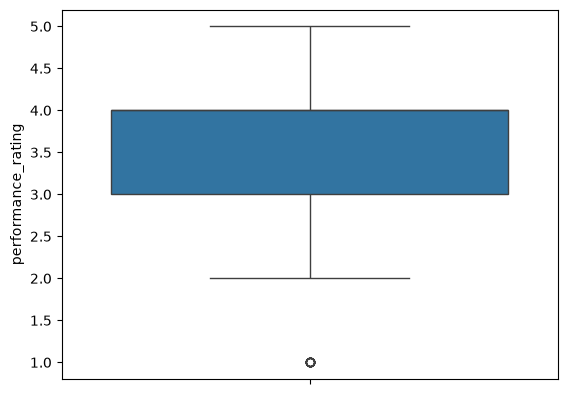

In [14]:
sns.boxplot(df['performance_rating'])

<Axes: ylabel='salary'>

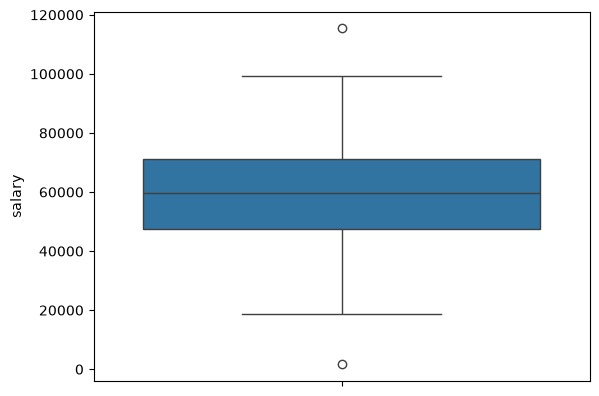

In [15]:
sns.boxplot(df['salary'])

In [16]:
#calculate iqr for salary
q1=df['salary'].quantile(0.25)
q3=df['salary'].quantile(0.75)
iqr=q3-q1
iqr

np.float64(23556.645000000004)

In [17]:
df=df[(df['salary']>=q1-1.5*iqr)&(df['salary']<=q3+1.5*iqr)]

<Axes: ylabel='salary'>

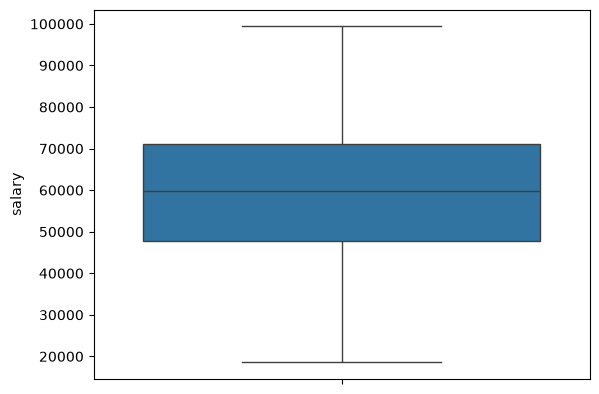

In [18]:
sns.boxplot(df['salary'])

In [19]:
q1=df['performance_rating'].quantile(0.25)
q3=df['performance_rating'].quantile(0.75)
iqr=q3-q1
iqr

np.float64(1.0)

In [20]:
df=df[(df['performance_rating']>=q1-1.5*iqr)&(df['performance_rating']<=q3+1.5*iqr)]

<Axes: ylabel='performance_rating'>

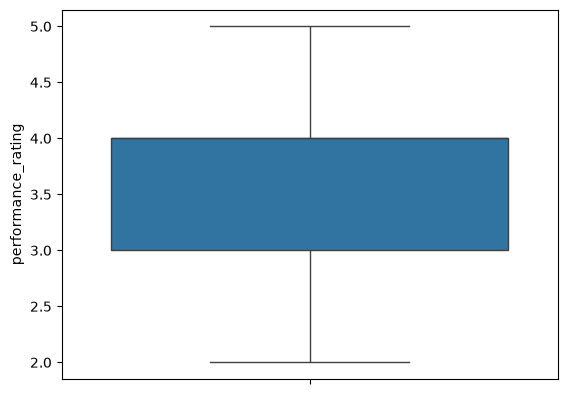

In [21]:
sns.boxplot(df['performance_rating'])

CONVERT DATA TYPES

In [22]:
df['join_date']=pd.to_datetime(df['join_date'],errors='coerce')
df['join_date'].dtype
df['join_date'].head()
df['join_date'].isnull().sum()
df['join_year']=df['join_date'].dt.year
df['join_month']=df['join_date'].dt.month
df['join_day']=df['join_date'].dt.day
df




,emp_name,department,join_date,salary,age,performance_rating,city,remote_work,join_year,join_month,join_day
0,Employee_1,Engineering,2018-01-01 00:00:00,60820.29,51.0,4.0,Pune,no,2018,1,1
2,Employee_3,HR,2018-01-16 16:08:02,98590.99,55.0,2.0,Mumbai,no,2018,1,16
3,Employee_4,Marketing,2018-01-24 12:12:02,71410.54,56.0,3.0,Mumbai,no,2018,1,24
4,Employee_5,Sales,2018-02-01 08:16:03,23547.43,43.0,4.0,Chennai,yes,2018,2,1
6,Employee_7,Sales,2018-02-17 00:24:05,48087.84,38.0,5.0,Pune,yes,2018,2,17
...,...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,Engineering,2024-04-30 15:43:57,60865.53,55.0,2.0,Chennai,no,2024,4,30
296,Employee_297,SALES,2024-05-08 11:47:58,64675.01,45.0,5.0,Delhi,no,2024,5,8
297,Employee_298,Sales,2024-05-16 07:51:58,43722.30,56.0,5.0,Pune,no,2024,5,16
298,Employee_299,Marketing,2024-05-24 03:55:59,71494.66,27.0,4.0,Mumbai,yes,2024,5,24


In [23]:
df.drop('join_date',axis=1,inplace=True)

In [24]:
df

,emp_name,department,salary,age,performance_rating,city,remote_work,join_year,join_month,join_day
0,Employee_1,Engineering,60820.29,51.0,4.0,Pune,no,2018,1,1
2,Employee_3,HR,98590.99,55.0,2.0,Mumbai,no,2018,1,16
3,Employee_4,Marketing,71410.54,56.0,3.0,Mumbai,no,2018,1,24
4,Employee_5,Sales,23547.43,43.0,4.0,Chennai,yes,2018,2,1
6,Employee_7,Sales,48087.84,38.0,5.0,Pune,yes,2018,2,17
...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,Engineering,60865.53,55.0,2.0,Chennai,no,2024,4,30
296,Employee_297,SALES,64675.01,45.0,5.0,Delhi,no,2024,5,8
297,Employee_298,Sales,43722.30,56.0,5.0,Pune,no,2024,5,16
298,Employee_299,Marketing,71494.66,27.0,4.0,Mumbai,yes,2024,5,24


ONE HOT ENCODING

In [25]:
df=pd.get_dummies(df,columns=['department','remote_work','city'],drop_first=True)

In [26]:
df

,emp_name,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,Employee_1,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,Employee_3,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,Employee_4,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,Employee_5,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,Employee_7,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,60865.53,55.0,2.0,2024,4,30,True,False,False,False,False,False,False,False,True,False,False,False
296,Employee_297,64675.01,45.0,5.0,2024,5,8,False,False,False,False,False,True,False,False,False,True,False,False
297,Employee_298,43722.30,56.0,5.0,2024,5,16,False,False,False,False,False,False,True,False,False,False,False,True
298,Employee_299,71494.66,27.0,4.0,2024,5,24,False,False,False,False,True,False,False,True,False,False,True,False


In [27]:
df

,emp_name,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,Employee_1,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,Employee_3,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,Employee_4,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,Employee_5,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,Employee_7,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,60865.53,55.0,2.0,2024,4,30,True,False,False,False,False,False,False,False,True,False,False,False
296,Employee_297,64675.01,45.0,5.0,2024,5,8,False,False,False,False,False,True,False,False,False,True,False,False
297,Employee_298,43722.30,56.0,5.0,2024,5,16,False,False,False,False,False,False,True,False,False,False,False,True
298,Employee_299,71494.66,27.0,4.0,2024,5,24,False,False,False,False,True,False,False,True,False,False,True,False


In [28]:
df.head()

,emp_name,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,Employee_1,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,Employee_3,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,Employee_4,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,Employee_5,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,Employee_7,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True


In [29]:
df

,emp_name,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,Employee_1,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,Employee_3,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,Employee_4,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,Employee_5,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,Employee_7,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,60865.53,55.0,2.0,2024,4,30,True,False,False,False,False,False,False,False,True,False,False,False
296,Employee_297,64675.01,45.0,5.0,2024,5,8,False,False,False,False,False,True,False,False,False,True,False,False
297,Employee_298,43722.30,56.0,5.0,2024,5,16,False,False,False,False,False,False,True,False,False,False,False,True
298,Employee_299,71494.66,27.0,4.0,2024,5,24,False,False,False,False,True,False,False,True,False,False,True,False


In [31]:
df

,emp_name,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,Employee_1,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,Employee_3,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,Employee_4,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,Employee_5,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,Employee_7,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,60865.53,55.0,2.0,2024,4,30,True,False,False,False,False,False,False,False,True,False,False,False
296,Employee_297,64675.01,45.0,5.0,2024,5,8,False,False,False,False,False,True,False,False,False,True,False,False
297,Employee_298,43722.30,56.0,5.0,2024,5,16,False,False,False,False,False,False,True,False,False,False,False,True
298,Employee_299,71494.66,27.0,4.0,2024,5,24,False,False,False,False,True,False,False,True,False,False,True,False


In [30]:
df

,emp_name,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,Employee_1,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,Employee_3,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,Employee_4,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,Employee_5,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,Employee_7,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Employee_296,60865.53,55.0,2.0,2024,4,30,True,False,False,False,False,False,False,False,True,False,False,False
296,Employee_297,64675.01,45.0,5.0,2024,5,8,False,False,False,False,False,True,False,False,False,True,False,False
297,Employee_298,43722.30,56.0,5.0,2024,5,16,False,False,False,False,False,False,True,False,False,False,False,True
298,Employee_299,71494.66,27.0,4.0,2024,5,24,False,False,False,False,True,False,False,True,False,False,True,False


In [32]:
df.drop('emp_name',inplace=True,axis=1)

In [33]:
df

,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,60820.29,51.0,4.0,2018,1,1,True,False,False,False,False,False,False,False,False,False,False,True
2,98590.99,55.0,2.0,2018,1,16,False,False,True,False,False,False,False,False,False,False,True,False
3,71410.54,56.0,3.0,2018,1,24,False,False,False,False,True,False,False,False,False,False,True,False
4,23547.43,43.0,4.0,2018,2,1,False,False,False,False,False,False,True,True,True,False,False,False
6,48087.84,38.0,5.0,2018,2,17,False,False,False,False,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,60865.53,55.0,2.0,2024,4,30,True,False,False,False,False,False,False,False,True,False,False,False
296,64675.01,45.0,5.0,2024,5,8,False,False,False,False,False,True,False,False,False,True,False,False
297,43722.30,56.0,5.0,2024,5,16,False,False,False,False,False,False,True,False,False,False,False,True
298,71494.66,27.0,4.0,2024,5,24,False,False,False,False,True,False,False,True,False,False,True,False


In [34]:
df.isna().sum()

salary                    0
age                       0
performance_rating        0
join_year                 0
join_month                0
join_day                  0
department_Engineering    0
department_Finance        0
department_HR             0
department_MARKETING      0
department_Marketing      0
department_SALES          0
department_Sales          0
remote_work_yes           0
city_Chennai              0
city_Delhi                0
city_Mumbai               0
city_Pune                 0
dtype: int64

In [35]:
df=df.astype(int)

In [36]:
df

,salary,age,performance_rating,join_year,join_month,join_day,department_Engineering,department_Finance,department_HR,department_MARKETING,department_Marketing,department_SALES,department_Sales,remote_work_yes,city_Chennai,city_Delhi,city_Mumbai,city_Pune
0,60820,51,4,2018,1,1,1,0,0,0,0,0,0,0,0,0,0,1
2,98590,55,2,2018,1,16,0,0,1,0,0,0,0,0,0,0,1,0
3,71410,56,3,2018,1,24,0,0,0,0,1,0,0,0,0,0,1,0
4,23547,43,4,2018,2,1,0,0,0,0,0,0,1,1,1,0,0,0
6,48087,38,5,2018,2,17,0,0,0,0,0,0,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,60865,55,2,2024,4,30,1,0,0,0,0,0,0,0,1,0,0,0
296,64675,45,5,2024,5,8,0,0,0,0,0,1,0,0,0,1,0,0
297,43722,56,5,2024,5,16,0,0,0,0,0,0,1,0,0,0,0,1
298,71494,27,4,2024,5,24,0,0,0,0,1,0,0,1,0,0,1,0
